In [1]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import accuracy_score
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
# Lire le CSV
df = pd.read_csv("data/df_num_cleaned.csv")

<Axes: >

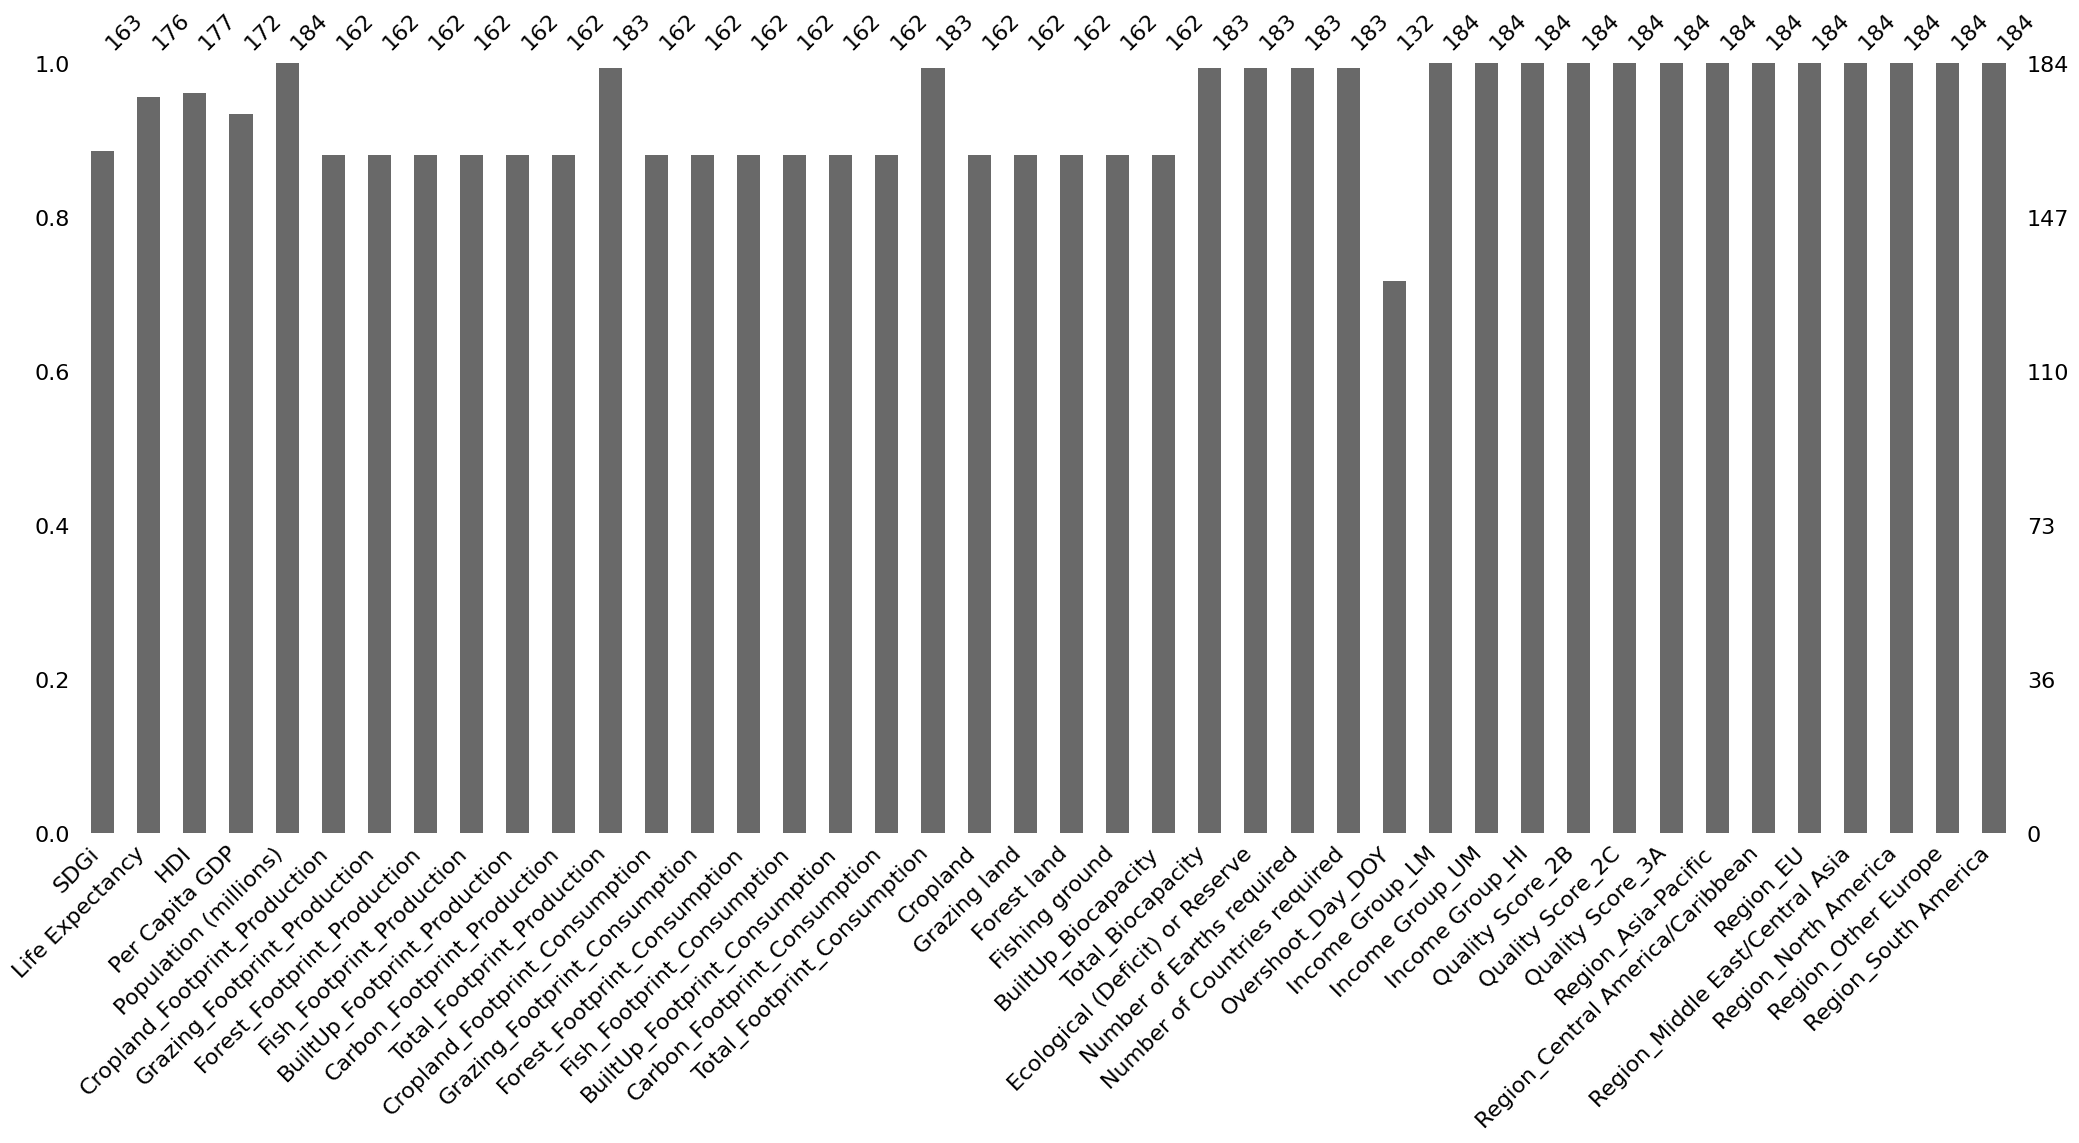

In [4]:
#give a barplot of the missing values
msno.bar(df)

On voit que la colonne qui possède le plus de données manquante est Overshoot day.
On a 18 variables pour qui il manque environ 10% des data.
3 variables pour qui il manque moins de 10% des variables.
Le reste des variables est complet (20 variables).

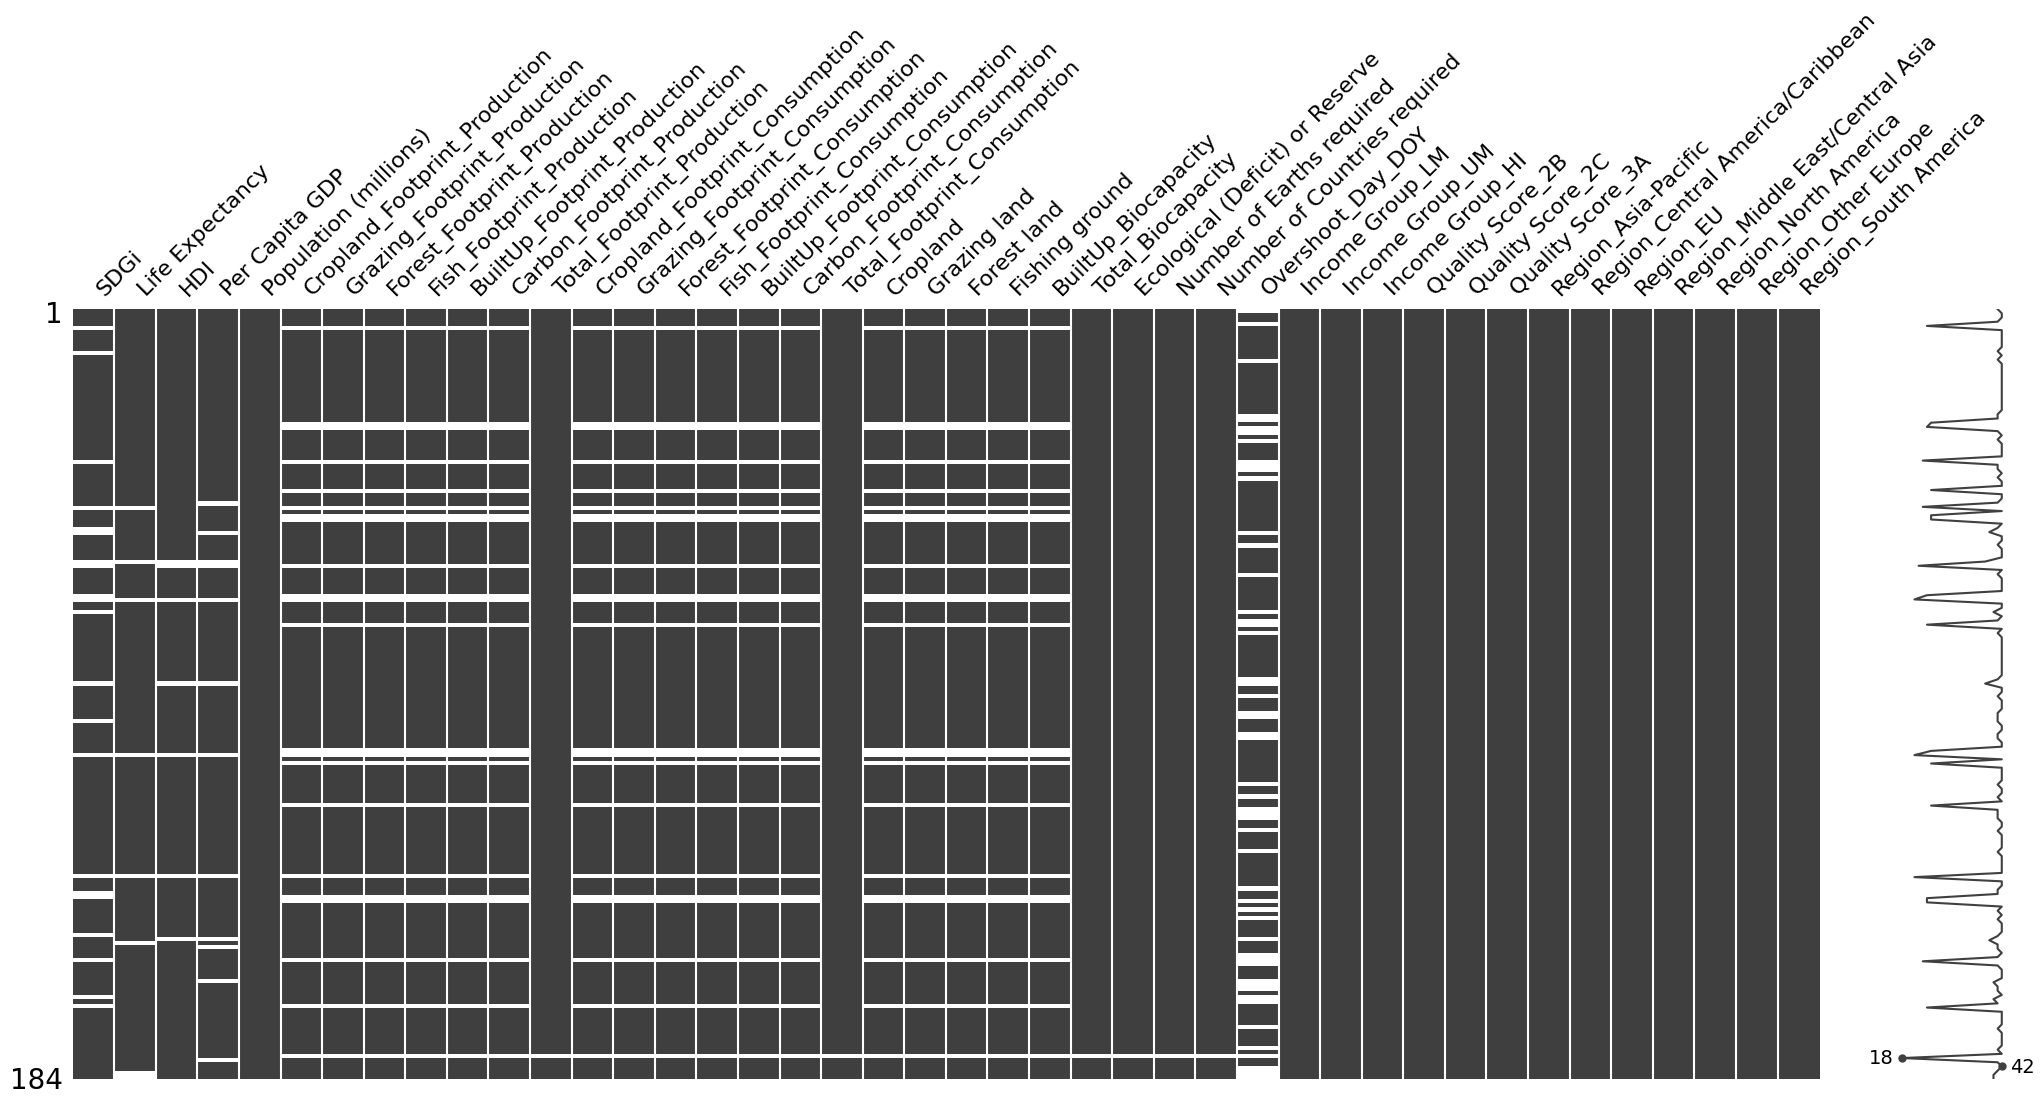

In [5]:
matrix_NA=msno.matrix(df, sparkline=True)

Lorsqu'on a un pays avec des NA, dans la plupart des cas, le pays possède des NA dans plusieurs variables différentes. 
=> ça semble vouloir dire que ce n'est pas dû au hasard donc plutôt MNAR ou MAR.

On voit aussi qu'on a les totaux des footprint consumption et footprint production, mais pas forcément les variables qui ont permis de calculer ces totaux.
=> dépendance entre les variables manquantes
=> Donc on peut pas traiter les NA indépendamment.

On a des colonnes avec aucunes données manquantes.
=> Peuvent être utiles pour l'imputation ou les modèles.

On peut voir aussi que la répartition des NA est hétérogène, certains pays n'ont pas de NA et d'autre n'ont quasiment que des NA.

In [6]:
# La sparkline représente simplement le nombre de valeurs non-nulles par ligne
absence_per_col = df.isna().sum(axis=0)/184*100
print(absence_per_col)
len(absence_per_col)


SDGi                                11.413043
Life Expectancy                      4.347826
HDI                                  3.804348
Per Capita GDP                       6.521739
Population (millions)                0.000000
Cropland_Footprint_Production       11.956522
Grazing_Footprint_Production        11.956522
Forest_Footprint_Production         11.956522
Fish_Footprint_Production           11.956522
BuiltUp_Footprint_Production        11.956522
Carbon_Footprint_Production         11.956522
Total_Footprint_Production           0.543478
Cropland_Footprint_Consumption      11.956522
Grazing_Footprint_Consumption       11.956522
Forest_Footprint_Consumption        11.956522
Fish_Footprint_Consumption          11.956522
BuiltUp_Footprint_Consumption       11.956522
Carbon_Footprint_Consumption        11.956522
Total_Footprint_Consumption          0.543478
Cropland                            11.956522
Grazing land                        11.956522
Forest land                       

42

# Masque pour les NA

La coubre qu'on voit à droite des matrice de NA ça s'appelle la sparkline et ça représente le nombre de valeurs non-nulles par ligne. 
Dans le code suivant on prend la probabilité par colonne d'avoir un NA.
On ampute ensuite le code en attribuant un NA avec une certaine probabilité en fonction de la colonne. La probabilté correspond à celle de base du dataframe d'origine. 


Le code va générer pour chaque colonne un tableau contenant des booléens (qqchose binaire) avec une pbilité < probabilité(j) (=probabilité d'avoir un NA dans la colonne j) d'être TRUE. Puis dans la dernière ligne du code, si c'est TRUE alors on a un NA.

En comparant les probabilité par colonne des NA dans le tableau de base et dans le nouveau tableau, on voit qu'il y a beaucoup plus de NA dans le nouveau tableau donc il y a un problème.

In [7]:
# Probabilités de NA par colonne (entre 0 et 1)
absence_per_col = df.isna().sum(axis=0) / len(df)  # shape: (n_cols,)

# Copie numpy
xmiss_df = df.to_numpy(dtype=float, copy=True)

n_rows, n_cols = xmiss_df.shape

for j in range(n_cols):
    p_j = absence_per_col.iloc[j]  # probabilité de NA pour la colonne j
    miss_mask = np.random.uniform(0, 1, size=n_rows) < p_j
    xmiss_df[miss_mask, j] = np.nan

<Axes: >

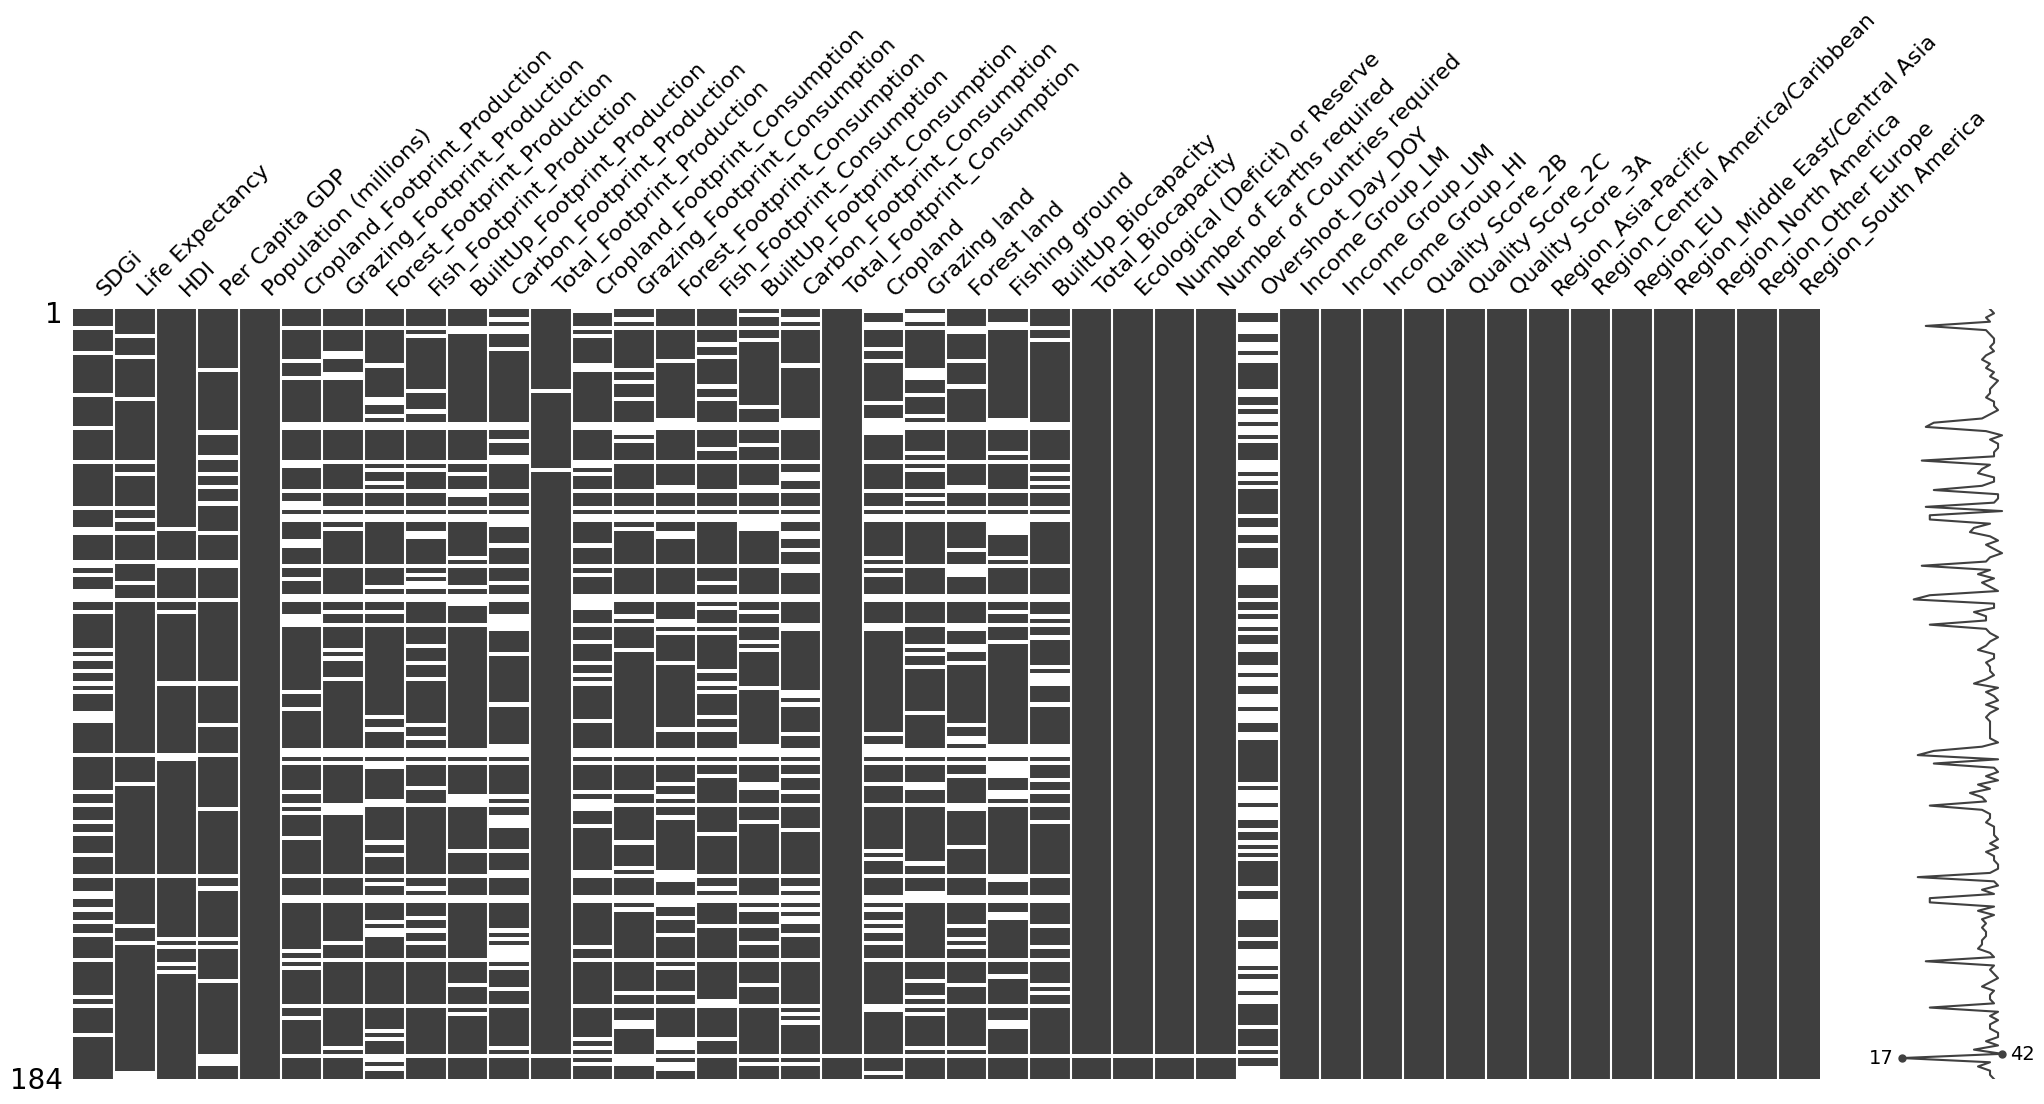

In [8]:
xmiss_df = pd.DataFrame(xmiss_df, columns=df.columns, index=df.index)
msno.matrix(xmiss_df)

In [23]:
absence_per_col2 = xmiss_df.isna().sum(axis=0) / len(xmiss_df)  # shape: (n_cols,)
absence_per_col2

SDGi                                0.211957
Life Expectancy                     0.097826
HDI                                 0.070652
Per Capita GDP                      0.119565
Population (millions)               0.000000
Cropland_Footprint_Production       0.211957
Grazing_Footprint_Production        0.190217
Forest_Footprint_Production         0.239130
Fish_Footprint_Production           0.222826
BuiltUp_Footprint_Production        0.179348
Carbon_Footprint_Production         0.271739
Total_Footprint_Production          0.016304
Cropland_Footprint_Consumption      0.250000
Grazing_Footprint_Consumption       0.217391
Forest_Footprint_Consumption        0.250000
Fish_Footprint_Consumption          0.222826
BuiltUp_Footprint_Consumption       0.228261
Carbon_Footprint_Consumption        0.255435
Total_Footprint_Consumption         0.005435
Cropland                            0.233696
Grazing land                        0.239130
Forest land                         0.239130
Fishing gr

In [24]:
absence_per_col

SDGi                                0.114130
Life Expectancy                     0.043478
HDI                                 0.038043
Per Capita GDP                      0.065217
Population (millions)               0.000000
Cropland_Footprint_Production       0.119565
Grazing_Footprint_Production        0.119565
Forest_Footprint_Production         0.119565
Fish_Footprint_Production           0.119565
BuiltUp_Footprint_Production        0.119565
Carbon_Footprint_Production         0.119565
Total_Footprint_Production          0.005435
Cropland_Footprint_Consumption      0.119565
Grazing_Footprint_Consumption       0.119565
Forest_Footprint_Consumption        0.119565
Fish_Footprint_Consumption          0.119565
BuiltUp_Footprint_Consumption       0.119565
Carbon_Footprint_Consumption        0.119565
Total_Footprint_Consumption         0.005435
Cropland                            0.119565
Grazing land                        0.119565
Forest land                         0.119565
Fishing gr

# Fin de la partie masque pour les NA

<Axes: >

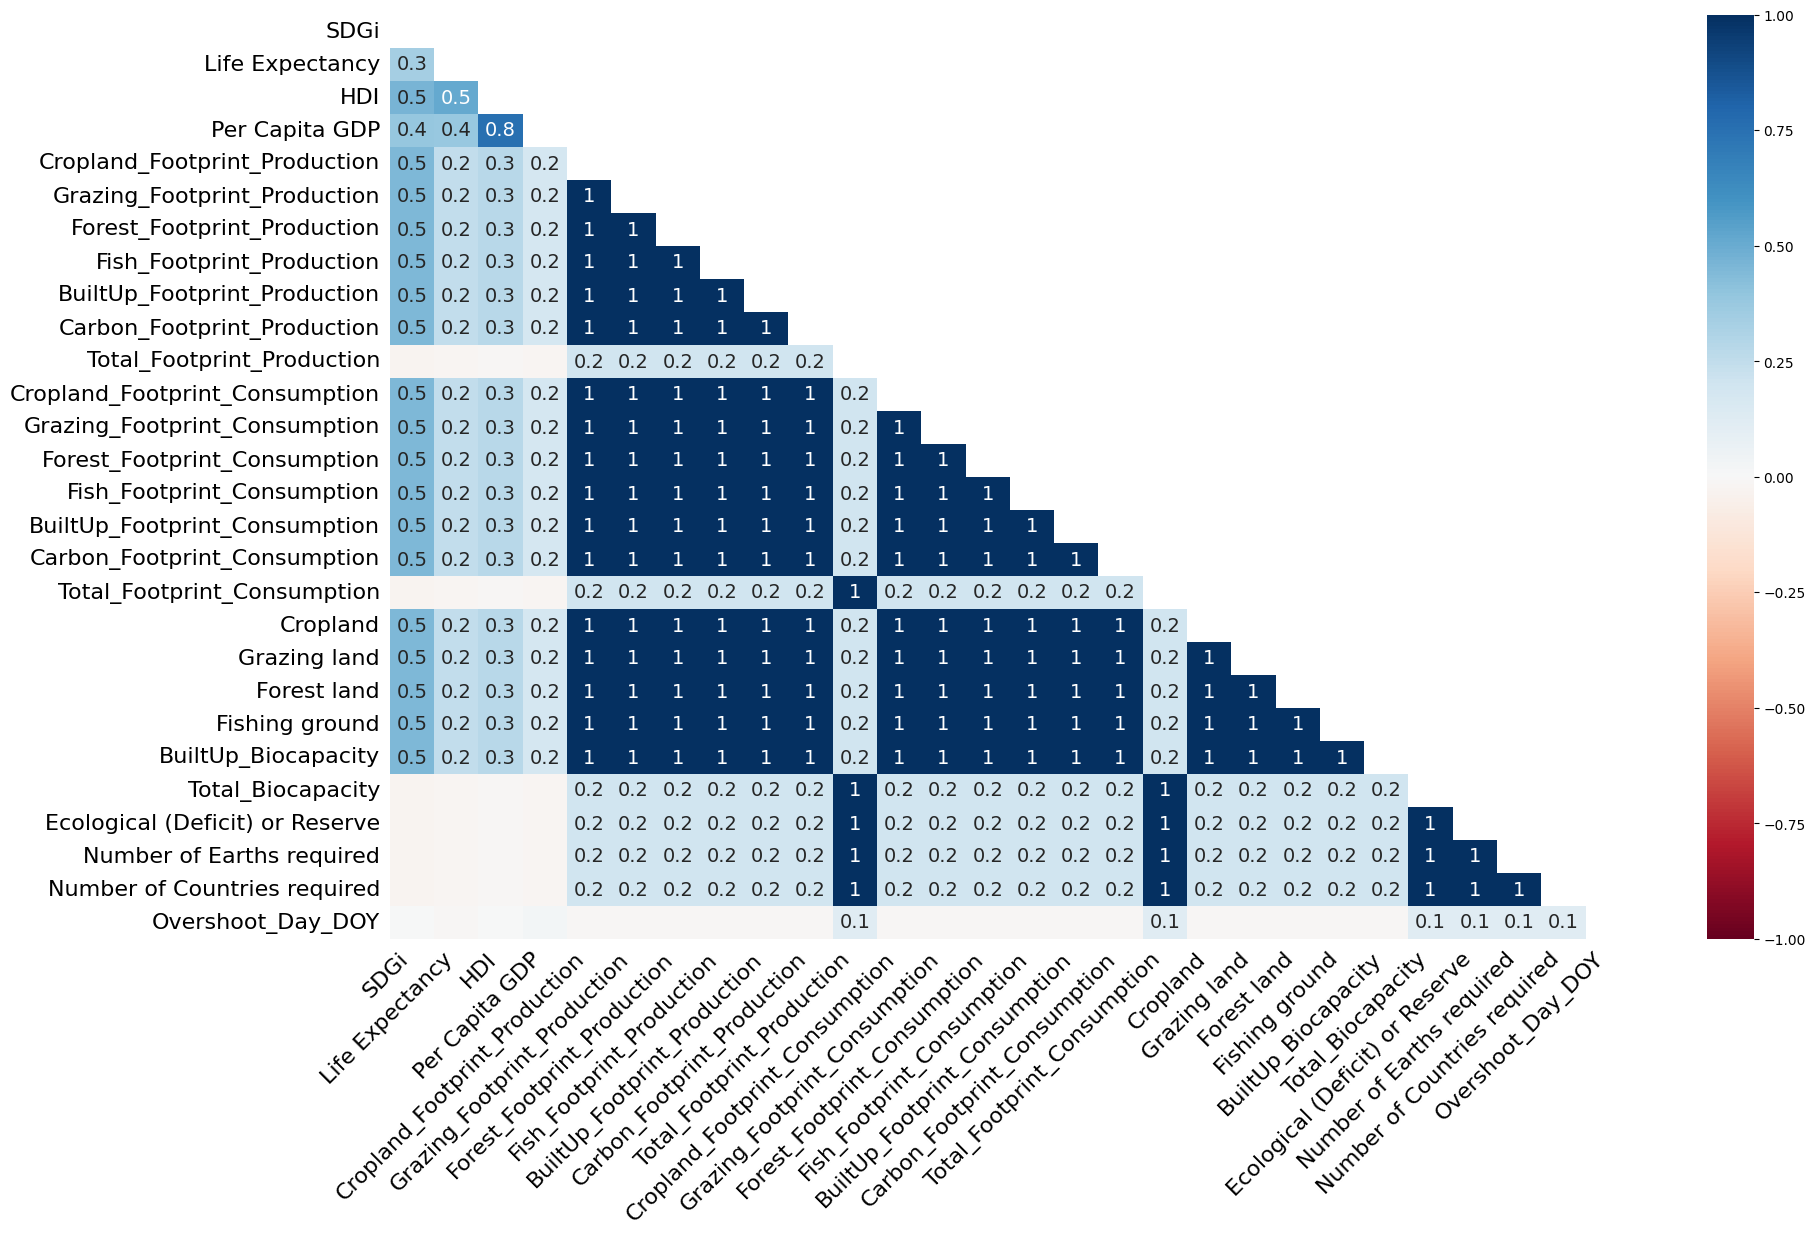

In [9]:
msno.heatmap(df)

They represent how correlated the fact that having null values in ones variable affect having null values in the second one.

Exemple: If you know where the null values in fishing ground are, that completely determines the null values in Cropland_footprint_Production.

Globalement: On voit qu'il y a beaucoup de 1 dans notre matrice => beaucoup de dépendance entre les NA au sein de notre jeu de données.

Les gros blocs de corrélations à 1 montre que les NA de ces variables sont dépendant les uns des autres.







On distingue 3 regroupements de variables qui ont des NA dépendants entre les 3 regroupements et au sein de leurs regroupements:

groupe1: 'Cropland_Footprint_Production','Grazing_Footprint_Production','Forest_Footprint_Production', 'Fish_Footprint_Production','BuiltUp_Footprint_Production', 'Carbon_Footprint_Production'

groupe 2: 'Cropland_Footprint_Consumption', 'Grazing_Footprint_Consumption', 'Forest_Footprint_Consumption', 'Fish_Footprint_Consumption','BuiltUp_Footprint_Consumption', 'Carbon_Footprint_Consumption',

groupe 3: 'Cropland','Grazing land','Forest land','Fishing ground','BuiltUp_Biocapacity'



Ainsi parmis ces 3 groupes, les variables sont toujours manquantes ensemble ou toujours présentes ensemble.

=> hypothèse: ces données viennent probablement de la même source de donnée. Ainsi si il en manque une il manque forcément les autres.







On a un 4ème regroupement de variables qui ont des NA dépendant seulement au sein de ce groupe:

groupe 4: 'Ecological (Deficit) or Reserve','Number of Earths required','Number of Countries required'

On a aussi les NA des totaux qui sont corrélés entre-eux.





On a un 5ème regroupement de variables qui ont des corrélation NA entre 0.3 et 0.5. Ce sont des variables sociaux économiques:

groupe 5: 'SDGi','Life Expectancy','HDI','Per Capita GDP',

Ces données doivent provenir de base de donnée différentes des groupes 1, 2 et 3





Concernant overshoot day: On voit que les NA sont presque totalement indépendants des NA des autres variables.



Implication pour l'imputation => il faudra prendre en compte ces dépendance de NA entre les variables.
Exemple: si on impute un NA des production, alors il faut qu'on impute aussi les consumption et les variables de biocapacité/land use (cropland, grazing land...)

=> de manière général, il faudra qu'on mette les coefficient de corrélation entre les NA.


# Exercice 4 - Lab1_MOOC_Expert_fr

In [10]:
df_wo_NA = df.dropna()

In [11]:
features_names=[
    'SDGi',
    'Life Expectancy',
    'HDI', 
    'Per Capita GDP', 
    'Population (millions)', 
    'Cropland_Footprint_Production', 
    'BuiltUp_Footprint_Production', 
    'Cropland_Footprint_Consumption', 
    'Forest_Footprint_Consumption', 
    'Fish_Footprint_Consumption', 
    'Cropland', 
    'Grazing land', 
    #'Ecological (Deficit) or Reserve', 
    #'Number of Earths required', 
    'Income Group_HI', 
    'Region_Other Europe'
]


In [12]:
xfull=df_wo_NA[features_names]
Y = df_wo_NA["Overshoot_Day_DOY"]

In [13]:
pd.DataFrame(xfull, columns=features_names).head()


,SDGi,Life Expectancy,HDI,Per Capita GDP,Population (millions),Cropland_Footprint_Production,BuiltUp_Footprint_Production,Cropland_Footprint_Consumption,Forest_Footprint_Consumption,Fish_Footprint_Consumption,Cropland,Grazing land,Income Group_HI,Region_Other Europe
1,71.0,78.4580,0.792,5046.032611,2.882740,0.362065,0.042248,0.547458,0.207561,0.040595,0.362065,0.195718,0,1
2,70.9,76.6930,0.746,4759.830054,42.228398,0.249653,0.037283,0.642917,0.163528,0.013793,0.249653,0.249356,0,0
5,72.8,76.5200,0.842,10076.395406,44.361102,2.207423,0.092705,0.908614,0.276678,0.083593,2.207423,1.721421,0,0
6,71.8,74.9450,0.771,4406.741763,2.951750,0.208557,0.035763,0.482839,0.267196,0.000756,0.208557,0.263465,0,0
7,75.6,82.7488,0.943,57032.237052,24.898199,1.921158,0.040870,0.765995,0.947139,0.112822,1.921158,4.613393,1,0


In [14]:
n, d = xfull.shape

In [15]:
print(d)

14


In [16]:
len(xfull)

106

### Génération de NA MCAR:

#### Question 1 : génération d'un masque MCAR basique

In [17]:
p = [0.3, 0.6, 0.8]
xmiss = np.copy(xfull)
for j in range(5):
  miss_id = np.random.uniform(0, 1, size=n) < p[0]
  xmiss[miss_id, j] = np.nan
for j in range(5, 10):
  miss_id = np.random.uniform(0, 1, size=n) < p[1]
  xmiss[miss_id, j] = np.nan
for j in range(10, 14):
  miss_id = np.random.uniform(0, 1, size=n) < p[2]
  xmiss[miss_id, j] = np.nan

In [18]:
pd.DataFrame(xmiss,columns=features_names).head()

,SDGi,Life Expectancy,HDI,Per Capita GDP,Population (millions),Cropland_Footprint_Production,BuiltUp_Footprint_Production,Cropland_Footprint_Consumption,Forest_Footprint_Consumption,Fish_Footprint_Consumption,Cropland,Grazing land,Income Group_HI,Region_Other Europe
0,NaN,78.4580,0.792,5046.032611,2.882740,NaN,NaN,NaN,NaN,NaN,0.362065,NaN,NaN,1.0
1,NaN,76.6930,NaN,4759.830054,42.228398,NaN,0.037283,NaN,NaN,0.013793,NaN,0.249356,NaN,NaN
2,72.8,76.5200,0.842,10076.395406,44.361102,NaN,NaN,0.908614,NaN,NaN,NaN,NaN,NaN,0.0
3,NaN,74.9450,0.771,4406.741763,2.951750,NaN,NaN,NaN,NaN,0.000756,NaN,NaN,0.0,NaN
4,75.6,82.7488,0.943,NaN,NaN,1.921158,0.040870,NaN,NaN,NaN,NaN,4.613393,NaN,0.0


Le mécanisme est bien MCAR ici, car la probabilité d'être manquante pour une valeur ne dépend pas des valeurs des données. Le fait d'avoir des probabilités d'être manquant différents selon les variables n'est pas orthogonal au mécanisme MCAR.

##### Question 2 : utilisation de la librairie de visualisation missingno

<Axes: >

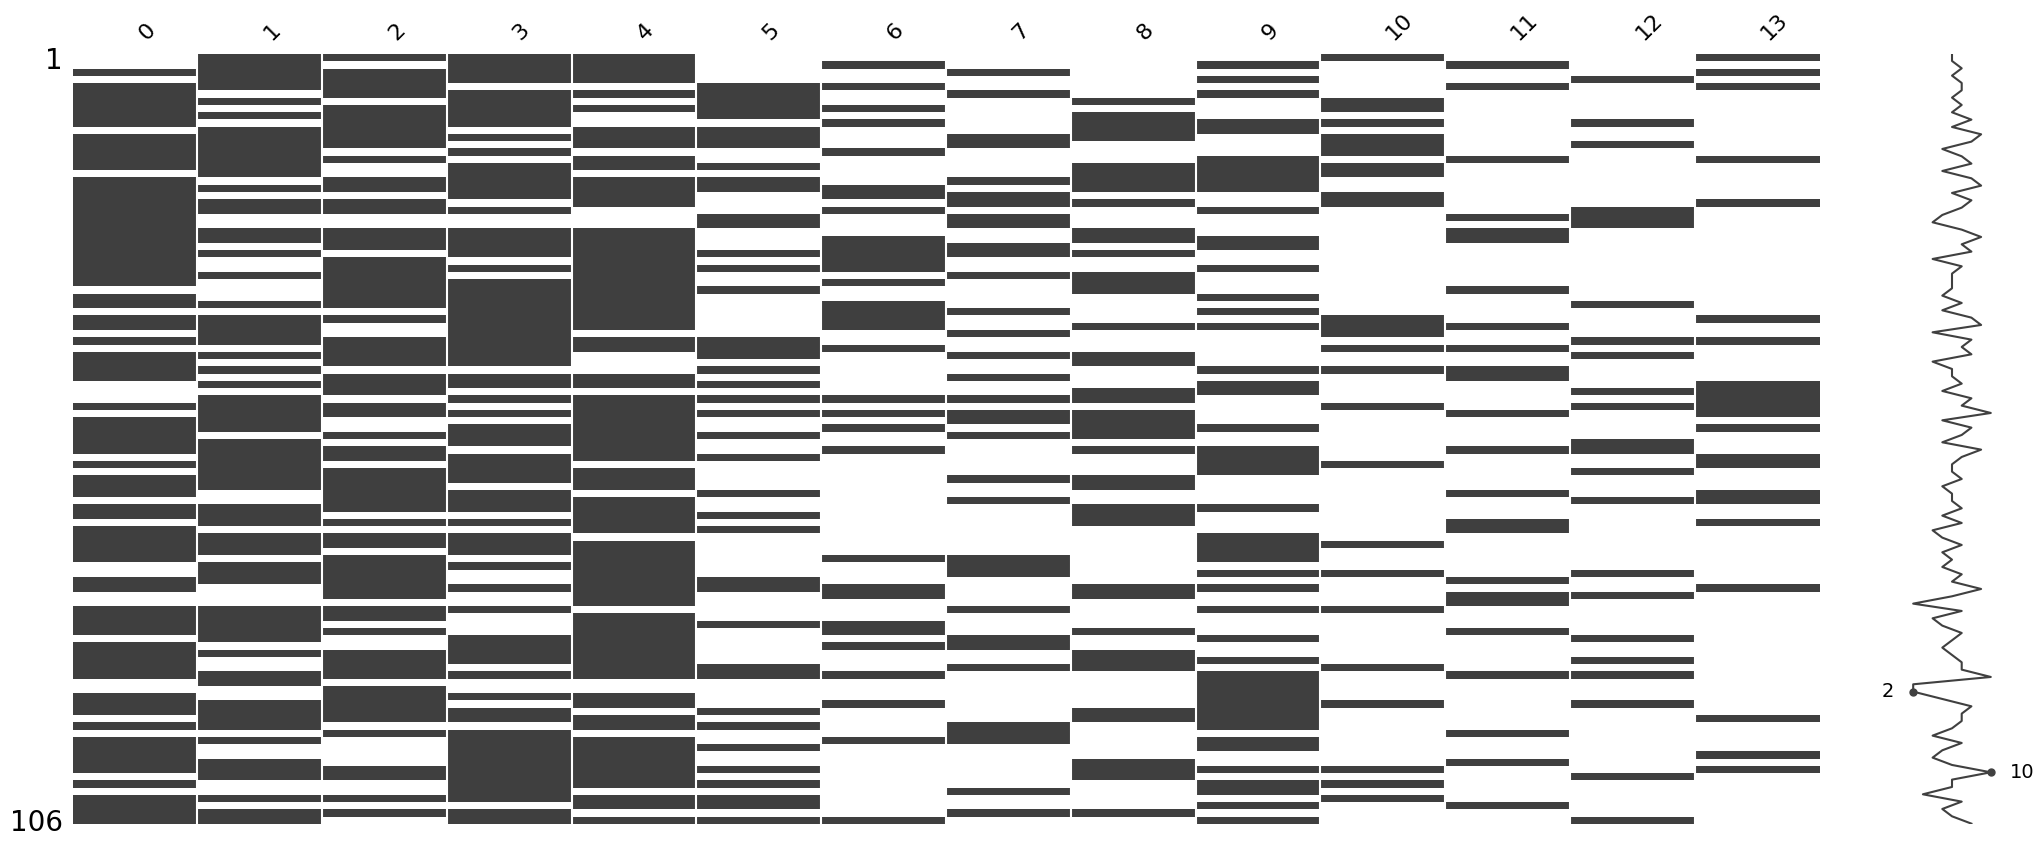

In [19]:
msno.matrix(pd.DataFrame(xmiss))

On voit que les 5 premières colonnes ont plus de valeurs observées que les 5 suivante et que les 4 dernières. C'est normal car la probabilité d'avoir des NA est passé de 0.3 à 0.6 puis à 0.8.

<Axes: >

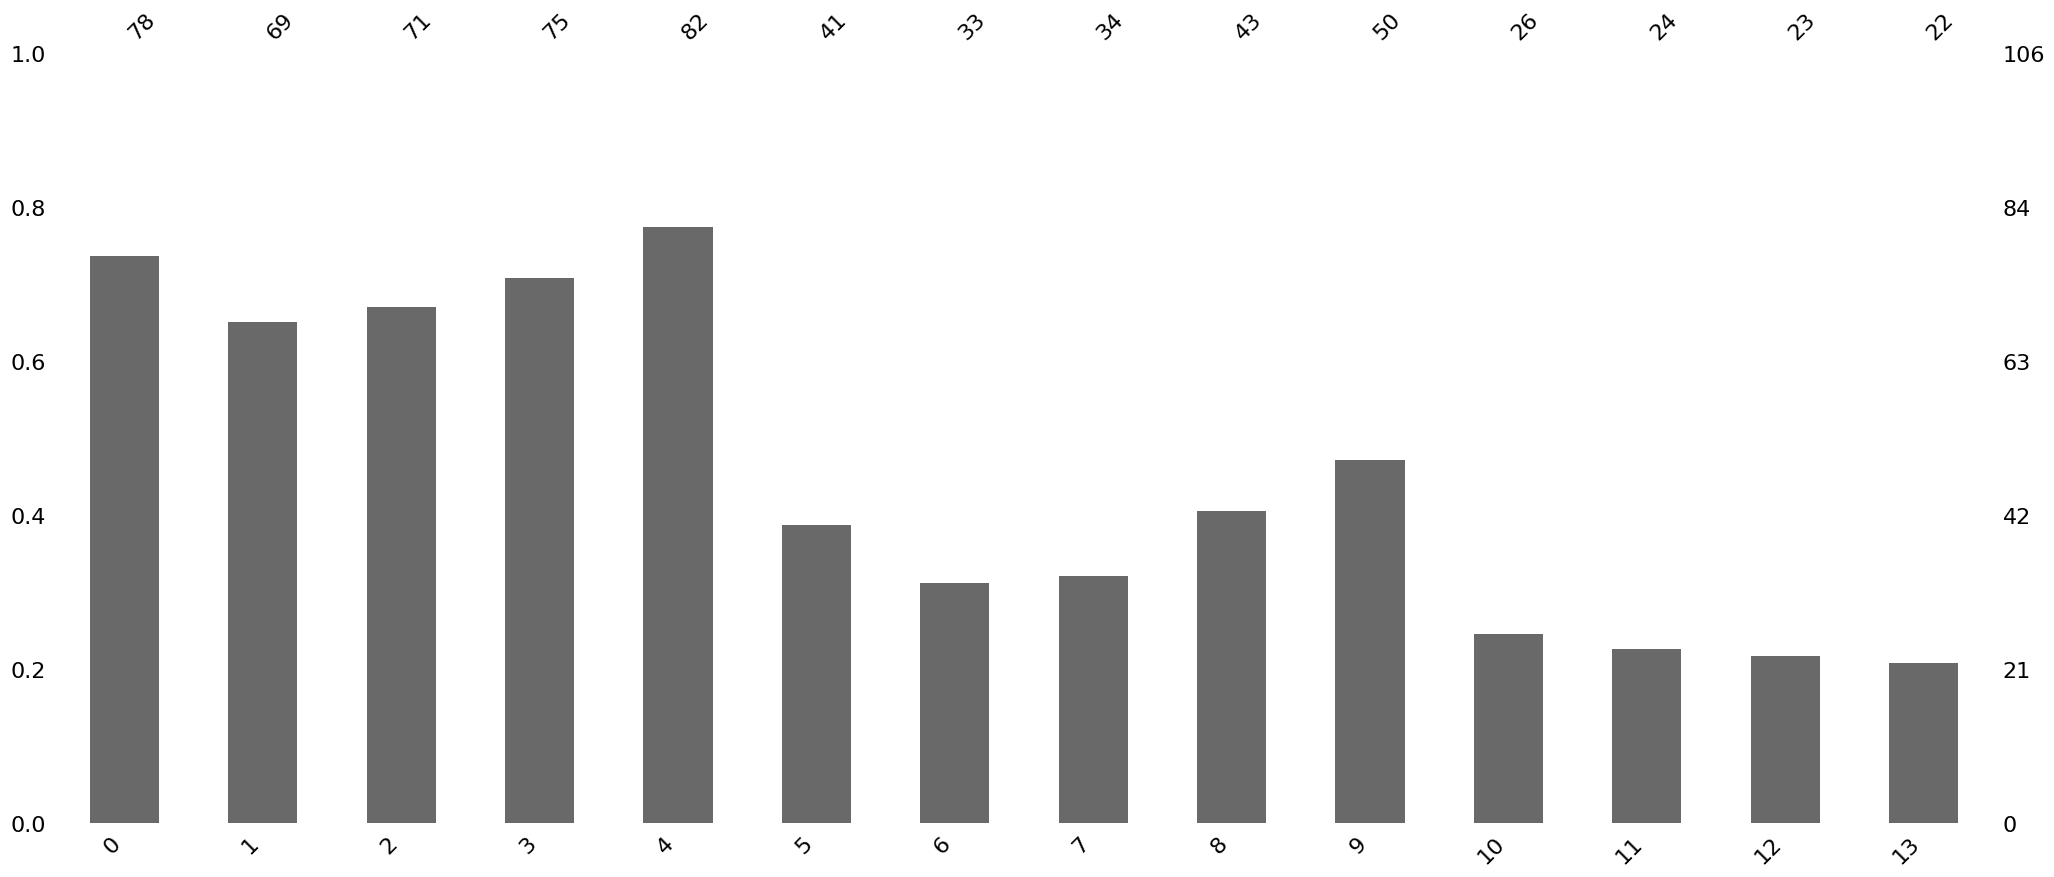

In [20]:
msno.bar(pd.DataFrame(xmiss))

On voit que plus on va vers la droite dans les colonnes, moins il y a de données observées (comme dans la matrice).
On voit pour les 5 premières colonnes qu'il y a environ 30% de NA, puis pour les 5 à 10 environ 50-60% de NA et enfin pour les 4 dernières environ 80% de NA

#### Question 3 : génération d'un masque avec dépendance

In [21]:
p = 0.3
xmiss = np.copy(xfull)
for j in range(5):
  miss_id = np.random.uniform(0, 1, size=n) < p
  xmiss[miss_id, j] = np.nan
  xmiss[miss_id, j+5] = np.nan

<Axes: >

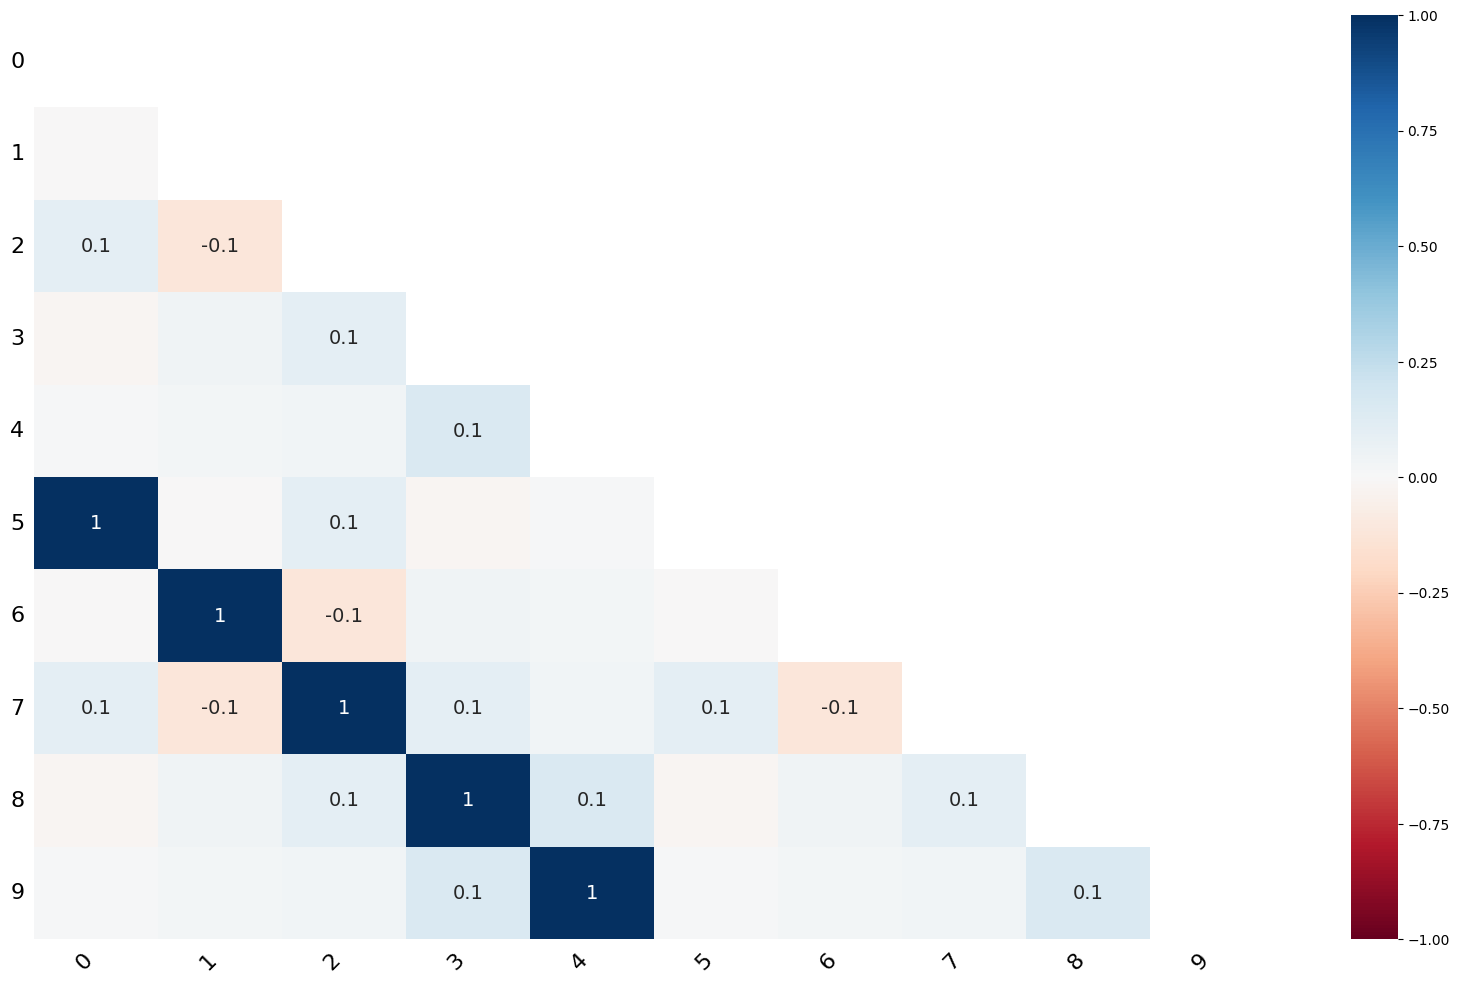

In [22]:
msno.heatmap(pd.DataFrame(xmiss))

On observe avec la fonction heatmap que la présence des 5 premières variables est directement liée (avec corrélation de 1) à la présence des 5 suivantes, comme attendu avec la génération du masque.

Le mécanisme de données manquantes reste MCAR. La probabilité d'être manquante pour chaque valeur ne dépendant pas des valeurs des données. Ici, nous avons introduit une dépendance entre les masques M.,j et M.,j+5 pour j=1,...,5
, mais le masque reste indépendant des valeurs des données, c'est-à-dire 
.

Je pense qu'ici il faut qu'on décrive quelles variables dépendent de quelle(s) variable. Pour qu'on soit en mesure de prédire les NA mais brmt correctement.

#### Question 4 : cas d'un masque dépendant du diagnostic

Ce qui est dit dans le MOOC:

Lorsqu'on a un jeu de donné qui contient déjà des NA (NA natives), le pb c'est qu'on peut pas trop savoir si on a bien imputer ou pas.

Une solution => introduire des NA avec la distribution des NA natives (mais pour ça faut savoir le mécanisme de l'absence donc MCAR, MNAR ou MAR) sur les lignes complètes et mesurer ensuite l'erreur des imputations sur ces nouveaux NA dont on connait la vraie valeur.